/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

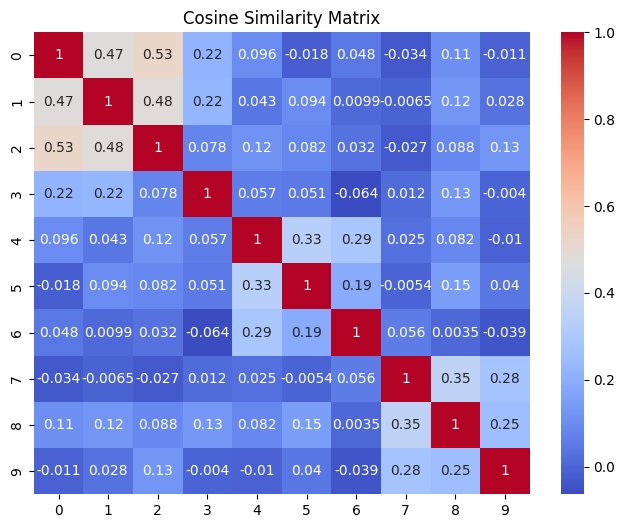

Top 2 similar sentences:
India won the cricket match by 5 wickets | Score: 0.68564045
The bowler took a hat-trick in the game | Score: 0.6440693


In [ ]:
# Install required library
!pip install sentence-transformers

# Import libraries
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 10 sentences (Cricket, Cooking, Cybersecurity)
sentences = [
    # Cricket (4)
    "The batsman hit a century in the match",
    "The bowler took a hat-trick in the game",
    "India won the cricket match by 5 wickets",
    "The captain made a strategic field placement",

    # Cooking (3)
    "Add spices and cook the vegetables slowly",
    "The chef prepared a delicious pasta dish",
    "Boil the rice until it becomes soft",

    # Cybersecurity (3)
    "Use strong passwords to protect your accounts",
    "Hackers can exploit vulnerabilities in systems",
    "Encryption ensures data security and privacy"
]

# Generate embeddings
embeddings = model.encode(sentences)

# Cosine similarity matrix
similarity_matrix = np.inner(embeddings, embeddings)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

# Query sentence
query = "The bowler took three wickets in one over"

# Query embedding
query_embedding = model.encode([query])

# Similarity with all sentences
scores = np.inner(query_embedding, embeddings)[0]

# Top 2 similar sentences
top_indices = scores.argsort()[-2:][::-1]

print("Top 2 similar sentences:")
for i in top_indices:
    print(sentences[i], "| Score:", scores[i])